In [21]:
%load_ext autoreload

In [31]:

%autoreload  2

import sys
sys.path.append('..')

import numpy as np

import logfft

import matplotlib.pyplot as plt


In [32]:

%matplotlib inline

In [130]:
x = np.array([4.4530543073792135, 5.51891864584486, 6.839903786706788, 8.477074371558148, 10.506111217615066, 13.020809784002031, 16.137416016204096, 19.999999999999996, 24.787115830585705, 30.720055559943635, 38.073078774317565, 47.1860906803012, 58.48035476425733, 72.47796636776954, 89.8259873761599])

y = np.array([1.419246570976687, 1.107597856811795, 0.9051507561387495, 0.6760424395810442, 0.48877192687396614, 0.35245656747422954, 0.25854939148559164, 0.18675835230015955, 0.14556227061873606, 0.09792561427637672, 0.06113648493474454, 0.02388667264513652, -0.0005956226214930379, -0.015919614580259128, -0.026911201419874655])

def f(xout): 

    return np.interp(xout, x, y)

In [137]:
logrmin = np.log10(x[0])
logrmax = np.log10(x[-1])

res = logfft.fftj0(f, logrmin, logrmax, n_pts=2048, q=0, kr=1.)

k_ary = res[0]
P_ary = res[1]
delt_ary = P_ary * k_ary**3 / (2 * np.pi**2)

In [138]:


fine_x = np.logspace(logrmin, logrmax, 2048)
fine_y = f(fine_x)

res_manual = (k_ary, np.array([
                2. / np.pi * k**2 * np.trapz(
                    fine_y * fine_x * np.sin(k * fine_x), fine_x
                ) for k in k_ary
            ]))

res_coarse = (k_ary, np.array([
                2. / np.pi * k**2 * np.trapz(
                    y * x * np.sin(k * x), x
                ) for k in k_ary
            ]))

                

(0.0004, 400.0)

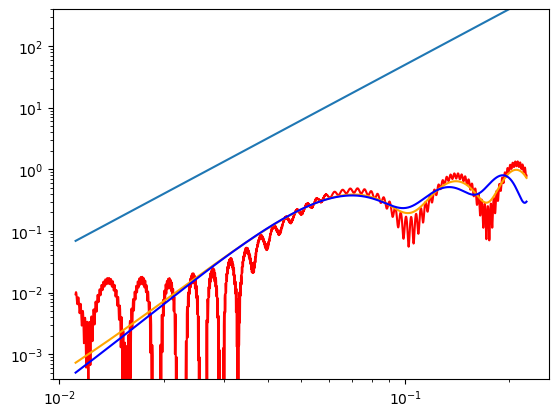

In [139]:
plt.figure() 



plt.loglog(k_ary, delt_ary, 'r')
plt.loglog(k_ary, res_manual[1], 'orange')
plt.loglog(k_ary, res_coarse[1], 'b')
plt.loglog(k_ary, 5e4*k_ary**3)

# plt.xlim(1e-1, 1)
plt.ylim(4e-4, 4e2)

In [111]:
k_ary[0]*x[-1]

1.0004571930682384